# ex-6 radar — every disk (polar) view in one notebook

All the disk/radar figures for the rotation story, collected from `ex-6_insub_rotation`
(mono) and its colored root counterpart, in one self-contained notebook. Each disk keeps
the **direction** of the estimate rather than reducing it to a scalar: a panel is the KDE
cloud (or raw dots) of a replicate's coordinates in a chosen 2-D plane, with the unit
circle as the frame.

Figures, in order:

| figure | what it shows |
|---|---|
| growing-p / growing-n disks | $\Pi h_j/\lVert\Pi h_j\rVert$ in the $(b_2,b_3)$ plane, vs the $\hat\nu_j$ limit cloud |
| factor vs all planes | rows = estimated factors, columns = successive $(b_i,b_{i+1})$ planes |
| all three factors, growing p | every factor's cloud + mean arrow on one $(b_2,b_3)$ disk |
| raw $(b_1,b_2)$ projection | unnormalized coordinates — radial deficit includes every loss |
| angle gauge | each replicate placed at its true $\angle(b_j,h_j)$ on the unit arc |

Sweeps load from the shared `nb_outputs/ex6_df_{p,n}.parquet` cache (regenerated here if
missing — same model / designs / seed as ex-6, identical replicates).

The single-quantity disks use the mono theme; the figures that overlay all three factors
in one panel keep the canonical per-factor colors, since color is what separates them.

In [1]:
import sys
from io import BytesIO
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "sim").is_dir():
    if REPO_ROOT == REPO_ROOT.parent:
        raise FileNotFoundError("could not locate repo root (no 'sim' dir above cwd)")
    REPO_ROOT = REPO_ROOT.parent
for _p in (str(REPO_ROOT), str(REPO_ROOT / "sim")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from loguru import logger
logger.remove()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from fl_experiment_setup import ModelSpec, DesignSpec
from fl_experiment_runner import run_experiment
from fl_plot import (grid, Row, Band, MeanCI, BoxDist, RefOverlay, DiskDensity,
                     Theme, THEME)

DATA_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR = REPO_ROOT / "nb_outputs" / "ex6_radar"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ONE color for every per-factor mark (factors are not compared across panels);
# ci_caps zeroed out -> measured-mean dots carry no error bars.
FACTOR_HATCHES = ("", "//", "xx", "..", "\\\\", "++")   # per-factor identity, colorless
MONO_THEME = Theme(factor_colors=("tab:gray",) * 6,
                   factor_cmaps=("Blues",) * 6,
                   factor_hatches=FACTOR_HATCHES,
                   ci_caps=dict(fmt="none", ecolor="black", elinewidth=0.0, capsize=0))
FIG_FORMATS = ("pdf",)
SAVE_FIGS = False   # default: figures are NOT written to disk; enable one with out(..., save=True)


def out(stem, save=None):
    """out_path for grid(): OUT_DIR/stem when saving is on (globally via
    SAVE_FIGS, or per-figure via save=True), else None."""
    return OUT_DIR / stem if (SAVE_FIGS if save is None else save) else None


def show(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    display(Image(data=buf.getvalue()))
    plt.close(fig)


# Canonical diagonal-Gram model (factor 1 market-like, c = [1.25, 1, 1]).
model = ModelSpec(
    k_factors=3,
    factor_vols=[0.16, 0.08, 0.06],
    beta_samplers=[
        {"distribution": "normal", "loc": 1.0, "scale": 0.5},
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},
    ],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},
)
HEAVY_TAIL = dict(
    factor_return_sampler={"distribution": "student_t", "df": 6, "loc": 0.0, "scale": 1.0},
    idio_return_sampler={"distribution": "student_t", "df": 5, "loc": 0.0, "scale": 1.0},
)
N_REPS, SEED = 1000, 20260511
_TAILS = r"(Factor Returns ~ $\mathcal{T}_6$, Idiosyncratic Returns ~ $\mathcal{T}_5$)"
print("ready")

ready


In [2]:
from sim_theorem_partii import Eq6RHSAnalysis
from factor_lab.analyses.spectral import compute_true_eigenvalues
from factor_lab.analyses import compute_sine_alignment
from fl_experiment_setup import BaseExperiment


class Eq6RHSWithNu(Eq6RHSAnalysis):
    """Eq6RHSAnalysis plus the eigenvector coordinates of the k×k realized Gram."""

    def analyze(self, context) -> dict:
        result = super().analyze(context)
        k, n = context.k, context.T
        F = context.factor_returns.T
        if self.center:
            F = F - F.mean(axis=1, keepdims=True)
        c_half = np.sqrt((context.model.B ** 2).mean(axis=1))
        D_hat = (c_half[:, None] * (F @ F.T / n)) * c_half[None, :]
        vals, vecs = np.linalg.eigh(D_hat)
        result["nu_coords"] = vecs[:, np.argsort(vals)[::-1]]      # (k, k), col j = ν̂_j
        return result


class ProjectedSpectrumAnalysis:
    """Dual-Gram PCA with the eq.(18) split AND the raw projection coordinates."""

    def __init__(self, population_loading_directions_b_pop, loading_frame, center: bool = True):
        self.population_loading_directions_b_pop = population_loading_directions_b_pop
        self.loading_frame = loading_frame          # notional frame ℓ: normalized loading rows
        self.center = center

    def analyze(self, context) -> dict:
        k = context.k
        Y = context.security_returns.T
        if self.center:
            Y = Y - Y.mean(axis=1, keepdims=True)
        p, n = Y.shape
        G = Y.T @ Y
        eigenvalues, eigenvectors = np.linalg.eigh(G)
        order = np.argsort(eigenvalues)[::-1]
        top_k = order[:k]
        sv = np.sqrt(np.maximum(eigenvalues[top_k], 0.0))
        H = (Y @ eigenvectors[:, top_k]) / np.where(sv > 1e-14, sv, 1.0)   # (p, k)
        sin2_angle, _ = compute_sine_alignment(
            self.population_loading_directions_b_pop, H.T)
        coeffs = self.population_loading_directions_b_pop @ H              # (k, k)
        in_subspace = (coeffs ** 2).sum(axis=0)
        l_coords = self.loading_frame @ H                                  # (k, k): h_j vs the ℓ frame
        frame_diag = np.abs(np.diag(
            self.loading_frame @ self.population_loading_directions_b_pop.T))  # |⟨ℓ_i, b_i⟩| per rep
        return {"sin2_j": sin2_angle,
                "measured_out_of_subspace": 1.0 - in_subspace,             # ‖Π⊥h_j‖²
                "h_coords": coeffs,                                        # col j = Π h_j in b-basis
                "l_coords": l_coords, "frame_diag": frame_diag}


class InSubRotationExperiment(BaseExperiment):
    def __init__(self, center: bool = True):
        self.center = center

    def cell_setup(self, model, n: int, p: int):
        _, b_pop = compute_true_eigenvalues(model, model.k)
        ell = model.B / np.linalg.norm(model.B, axis=1, keepdims=True)     # notional frame ℓ
        return [ProjectedSpectrumAnalysis(b_pop, ell, center=self.center),
                Eq6RHSWithNu(center=self.center)]

    def record(self, n: int, p: int, merged: dict) -> list[dict]:
        k = len(merged["sin2_j"])
        C, W = merged["h_coords"], merged["nu_coords"]
        Lc, fd = merged["l_coords"], merged["frame_diag"]
        rows = []
        for j in range(k):
            rows.append({
                "n": n, "p": p, "j": j + 1,
                "sin2_j": float(merged["sin2_j"][j]),
                "rhs": float(merged["rhs"][j]), "floor": float(merged["floor"][j]),
                "rotation": float(merged["rotation"][j]),
                "measured_out_of_subspace": float(merged["measured_out_of_subspace"][j]),
                **{f"hb{i + 1}": float(C[i, j]) for i in range(k)},
                **{f"nu{i + 1}": float(W[i, j]) for i in range(k)},
                **{f"lb{i + 1}": float(Lc[i, j]) for i in range(k)},
                **{f"frame{i + 1}": float(fd[i]) for i in range(k)},
            })
        return rows

print("experiment classes defined")

experiment classes defined


In [3]:
design_p = DesignSpec(
    n_values=[63], p_values=[100, 500, 5000, 10000, 20000, 50000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)
design_n = DesignSpec(
    n_values=[20, 30, 45, 60, 63, 90, 120, 180, 250], p_values=[3000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)

_REQ = ({"hb1", "hb2", "hb3", "nu1", "nu2", "nu3", "rotation"}
        | {"lb1", "lb2", "lb3", "frame1", "frame2", "frame3"})


def load_or_run(path, design, label):
    if path.exists():
        d = pd.read_parquet(path)
        if (_REQ <= set(d.columns)
                and sorted(d["n"].unique()) == sorted(design.n_values)
                and sorted(d["p"].unique()) == sorted(design.p_values)
                and int(d.groupby(["n", "p", "j"]).size().max()) == design.n_reps):
            print(f"{label}: loaded cached sweep {path.name} ({len(d):,} rows)")
            return d
        print(f"{label}: cache mismatch — re-running")
    d = run_experiment(model, design, InSubRotationExperiment(), progress=True)
    d.to_parquet(path)
    print(f"{label}: ran sweep ({len(d):,} rows) → {path.name}")
    return d


df_p = load_or_run(DATA_DIR / "ex6_df_p.parquet", design_p, "growing-p")
df_n = load_or_run(DATA_DIR / "ex6_df_n.parquet", design_n, "growing-n")

growing-p: loaded cached sweep ex6_df_p.parquet (18,000 rows)
growing-n: loaded cached sweep ex6_df_n.parquet (27,000 rows)


In [4]:
def derive(df):
    C = df[["hb1", "hb2", "hb3"]].to_numpy()
    norm2 = (C ** 2).sum(axis=1)                       # ‖Π h_j‖²
    cjj = np.take_along_axis(C, (df["j"].to_numpy() - 1)[:, None], axis=1)[:, 0]
    sin2_in = 1.0 - cjj ** 2 / norm2                   # from coordinates
    # fold the arbitrary eigh sign by each vector's dominant coordinate
    sgn_h = np.sign(np.take_along_axis(C, np.abs(C).argmax(axis=1)[:, None], axis=1))[:, 0]
    W = df[["nu1", "nu2", "nu3"]].to_numpy()
    sgn_nu = np.sign(np.take_along_axis(W, np.abs(W).argmax(axis=1)[:, None], axis=1))[:, 0]
    nrm = np.sqrt(norm2)
    Lc = df[["lb1", "lb2", "lb3"]].to_numpy()
    sgn_l = np.sign(np.take_along_axis(Lc, np.abs(Lc).argmax(axis=1)[:, None], axis=1))[:, 0]
    return df.assign(
        sin2_in=sin2_in, diff_in_rot=df["rotation"] - sin2_in,   # limit − measured (predictor − realized)
        # unit-normalized in-subspace direction, sign-folded → comparable to ν̂
        hd1=sgn_h * C[:, 0] / nrm, hd2=sgn_h * C[:, 1] / nrm, hd3=sgn_h * C[:, 2] / nrm,
        nud1=sgn_nu * W[:, 0], nud2=sgn_nu * W[:, 1], nud3=sgn_nu * W[:, 2],
        # folded RAW cosines (no normalization): hf vs the b frame, lf vs the notional ℓ frame
        hf1=sgn_h * C[:, 0], hf2=sgn_h * C[:, 1], hf3=sgn_h * C[:, 2],
        lf1=sgn_l * Lc[:, 0], lf2=sgn_l * Lc[:, 1], lf3=sgn_l * Lc[:, 2],
        # angle gauge: each replicate at (cos, sin) of its TRUE angle to its own b_j —
        # polar angle in the plot = the actual angle ∠(b_j, h_j)
        ang_c=np.abs(cjj), ang_s=np.sqrt(np.clip(1.0 - cjj ** 2, 0.0, None)),
    )


df_p, df_n = derive(df_p), derive(df_n)

for nm, d in (("growing-p", df_p), ("growing-n", df_n)):
    ident = (d["sin2_j"] - d["measured_out_of_subspace"]) / (1 - d["measured_out_of_subspace"])
    print(f"{nm}: |sin2_in(coords) − sin2_in(identity)| max = "
          f"{(d['sin2_in'] - ident).abs().max():.2e};  "
          f"|‖c‖² − (1−oos)| max = "
          f"{((d[['hb1','hb2','hb3']]**2).sum(axis=1) - (1 - d['measured_out_of_subspace'])).abs().max():.2e}")


growing-p: |sin2_in(coords) − sin2_in(identity)| max = 1.15e-13;  |‖c‖² − (1−oos)| max = 5.55e-17
growing-n: |sin2_in(coords) − sin2_in(identity)| max = 2.18e-14;  |‖c‖² − (1−oos)| max = 5.55e-17


## Disks: the in-subspace direction, growing p and growing n

Each panel is the cloud of $\Pi h_j/\lVert\Pi h_j\rVert$ by its $(b_2, b_3)$
coordinates; the bottom row of the first figure is the $p\to\infty$ limit — the same
replicates' $\hat\nu_j$ from their realized factor Gram.

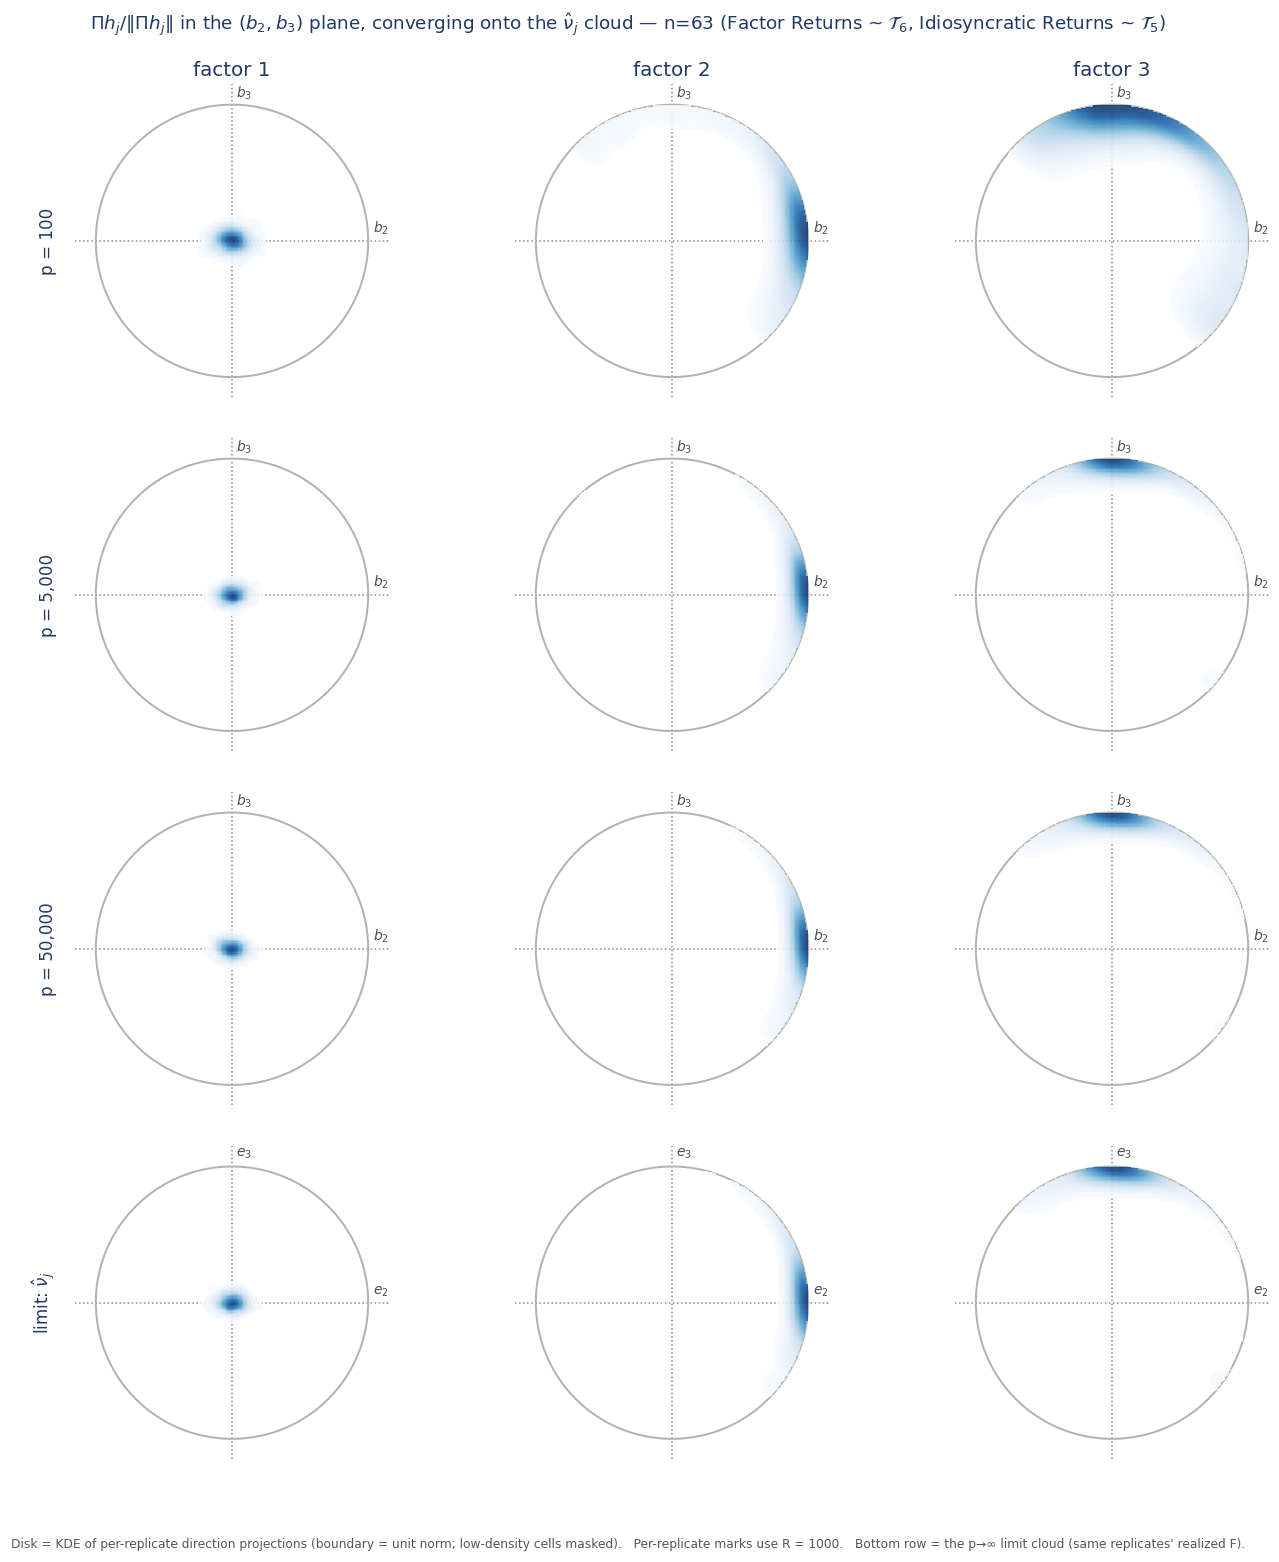

In [5]:
fig, _ = grid(df_p, "p",
              rows=[Row(DiskDensity("hd2", "hd3", at={"p": v}, labels=(r"$b_2$", r"$b_3$")),
                        ylabel=f"p = {v:,}", height=1.0) for v in (100, 5000, 50000)]
                   + [Row(DiskDensity("nud2", "nud3", at={"p": 50000},
                                      labels=(r"$e_2$", r"$e_3$")),
                          ylabel=r"limit: $\hat\nu_j$", height=1.0)],
              sharey=False,
              suptitle=rf"$\Pi h_j/\Vert\Pi h_j\Vert$ in the $(b_2, b_3)$ plane, "
                       rf"converging onto the $\hat\nu_j$ cloud — n=63 {_TAILS}",
              caption_extra="Bottom row = the p→∞ limit cloud (same replicates' realized F).",
              theme=MONO_THEME, formats=FIG_FORMATS, out_path=out("ex6_disks_growing_p"))
show(fig)

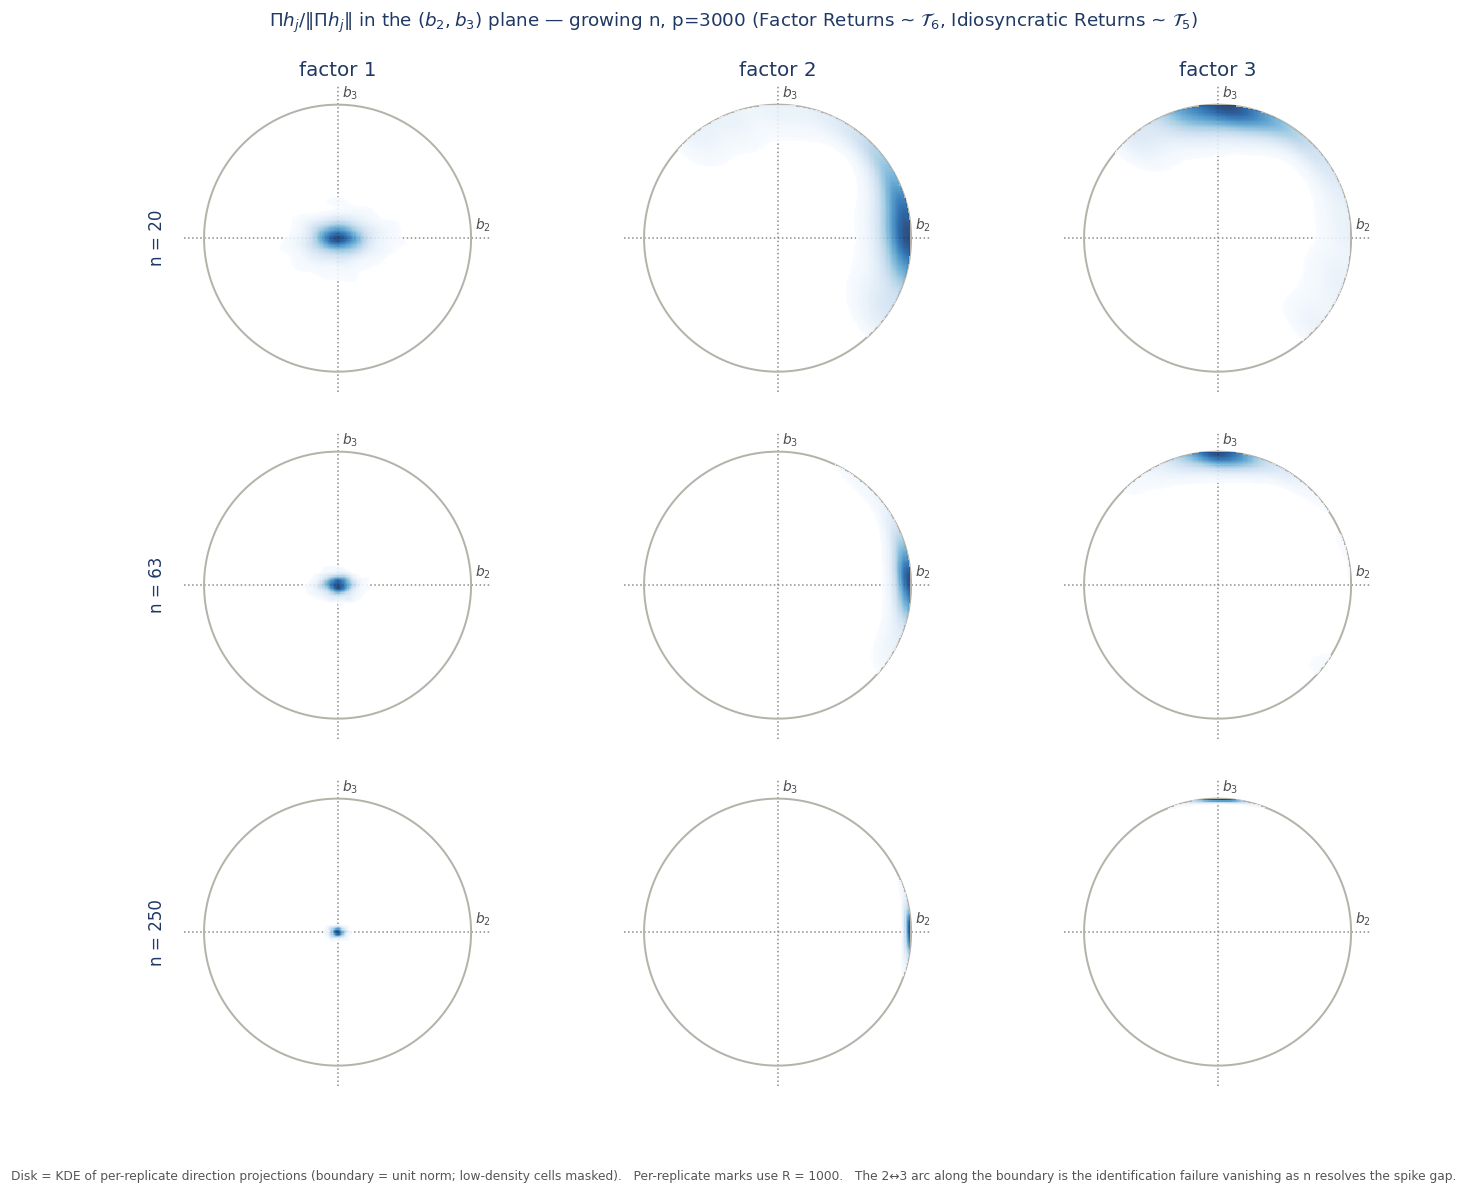

In [6]:
fig, _ = grid(df_n, "n",
              rows=[Row(DiskDensity("hd2", "hd3", at={"n": v}, labels=(r"$b_2$", r"$b_3$")),
                        ylabel=f"n = {v}", height=1.0) for v in (20, 63, 250)],
              sharey=False,
              suptitle=rf"$\Pi h_j/\Vert\Pi h_j\Vert$ in the $(b_2, b_3)$ plane — "
                       rf"growing n, p=3000 {_TAILS}",
              caption_extra="The 2↔3 arc along the boundary is the identification failure "
                            "vanishing as n resolves the spike gap.",
              theme=MONO_THEME, formats=FIG_FORMATS, out_path=out("ex6_disks_growing_n"))
show(fig)

## Each estimated factor against all planes

Rows = estimated factors $h_j$, columns = the successive $(b_i, b_{i+1})$ planes — each
row traces one estimated direction through every 2-D window of the population subspace.

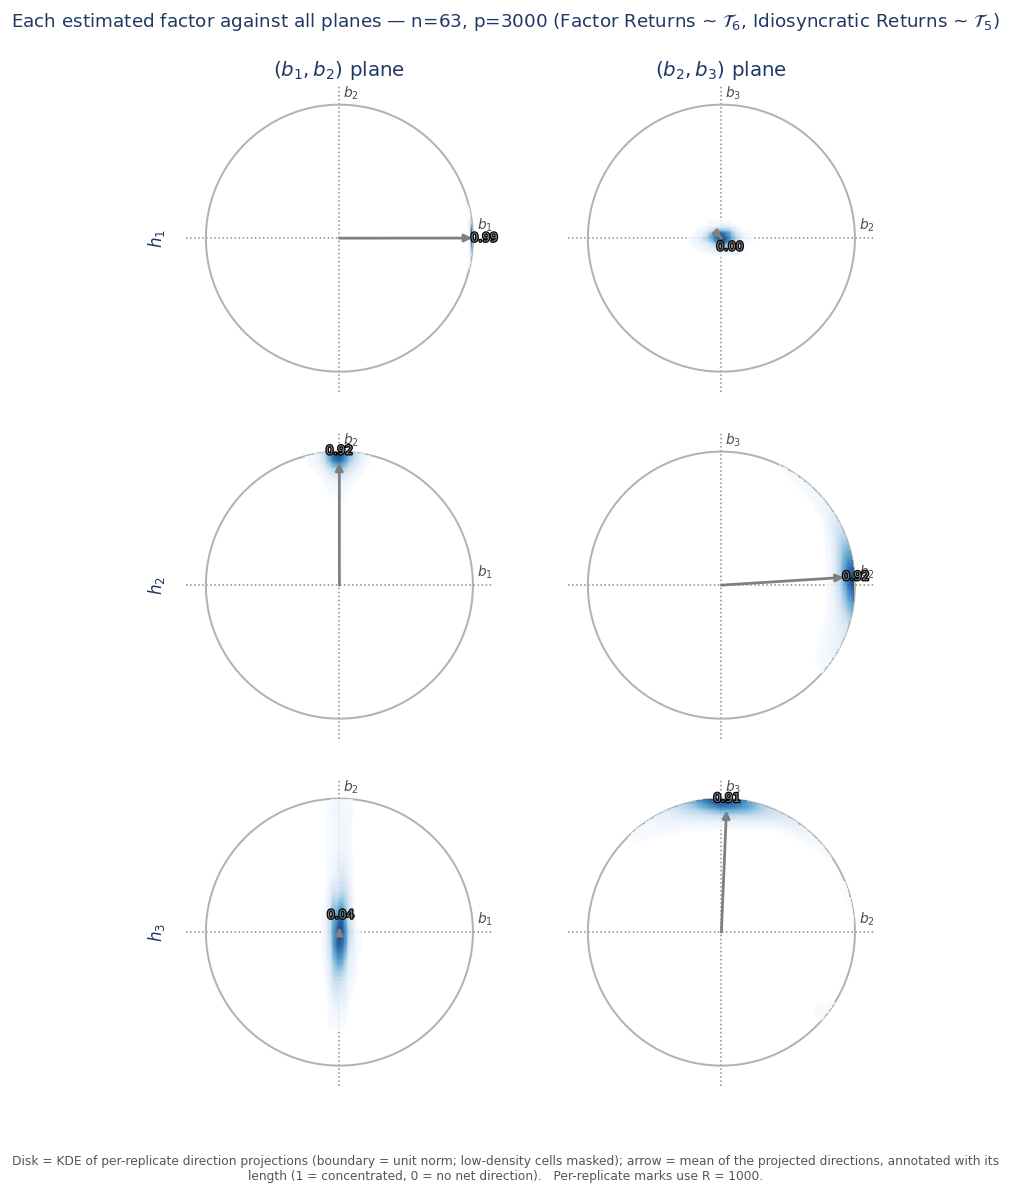

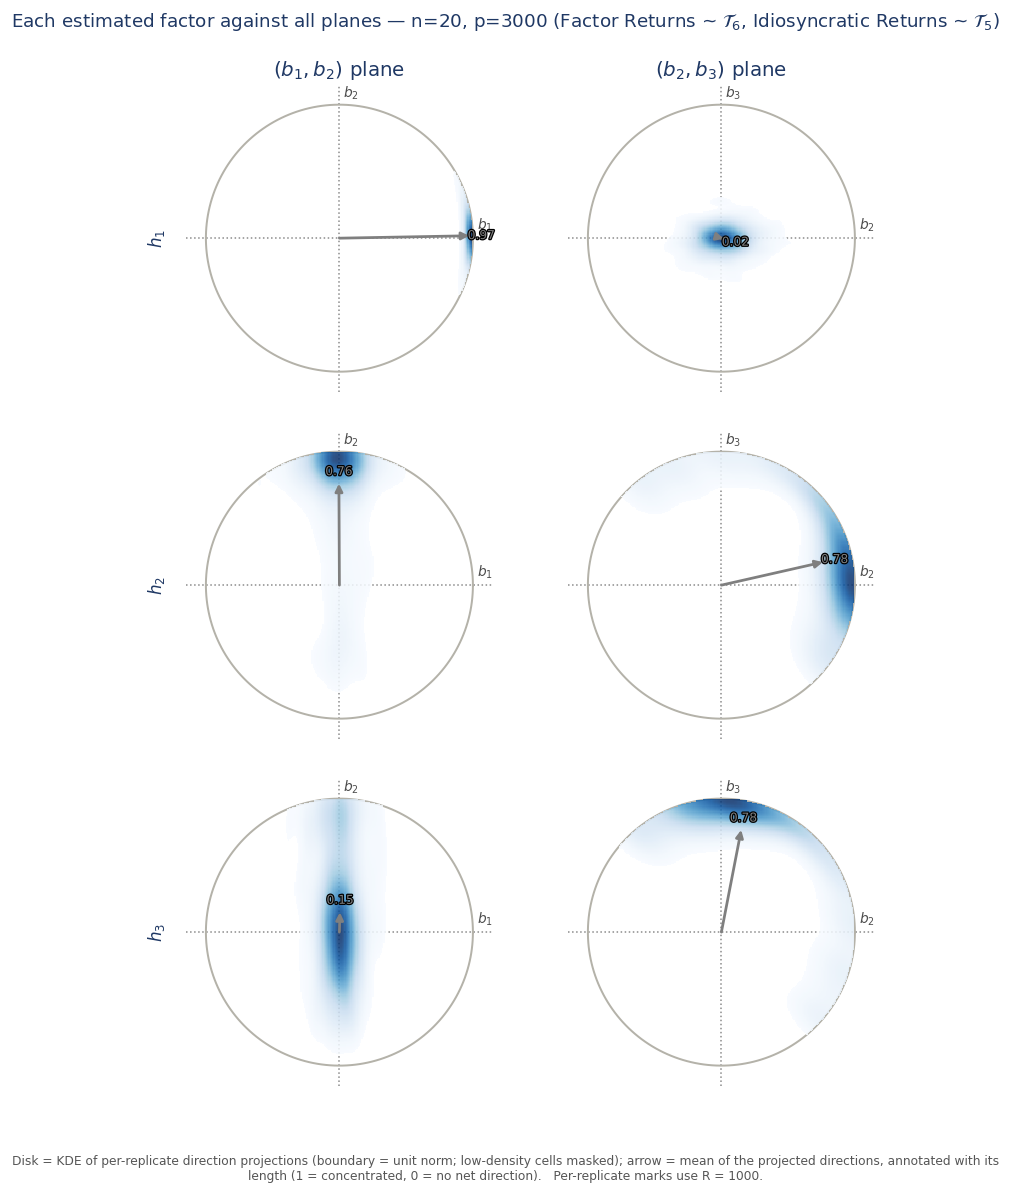

In [7]:
_K = 3
_HB = [f"hb{i}" for i in range(1, _K + 1)]
_PAIRS3 = [(1, 2), (2, 3)]


def factor_vs_all(df, at, at_label, out_stem):
    """3×2 grid: rows = estimated factors h_j, columns = successive (b_i, b_{i+1}) planes."""
    fig, _ = grid(
        df, list(at.keys())[0], factors=[1, 2],          # 2 layout columns
        col_titles=[rf"$(b_{i}, b_{i + 1})$ plane" for i, _ in _PAIRS3],
        rows=[Row(cells=[[DiskDensity(f"hd{i}", f"hd{i + 1}", factor=j, at=at,
                                      mean_arrow=True,
                                      labels=(rf"$b_{i}$", rf"$b_{i + 1}$"))]
                         for i, _ in _PAIRS3],
                  ylabel=rf"$h_{j}$", height=1.0)
              for j in range(1, _K + 1)],
        sharey=False, figsize=(7.6, 11.0), legend_row=None,
        suptitle=rf"Each estimated factor against all planes — {at_label} {_TAILS}",
        theme=MONO_THEME, formats=FIG_FORMATS, out_path=out(out_stem))
    show(fig)


factor_vs_all(df_n, {"n": 63}, "n=63, p=3000", "ex6_factor_vs_all_n63")
factor_vs_all(df_n, {"n": 20}, "n=20, p=3000", "ex6_factor_vs_all_n20")


## All three factors on one disk, growing p

With $k=3$ a single $(b_2, b_3)$ disk carries the whole model: factors 2 and 3 at their
axes, factor 1 at the origin (its mass is on $b_1$), each with its mean arrow. Columns
walk $p$ left-to-right into the $\hat\nu$ limit. Canonical factor colors here.

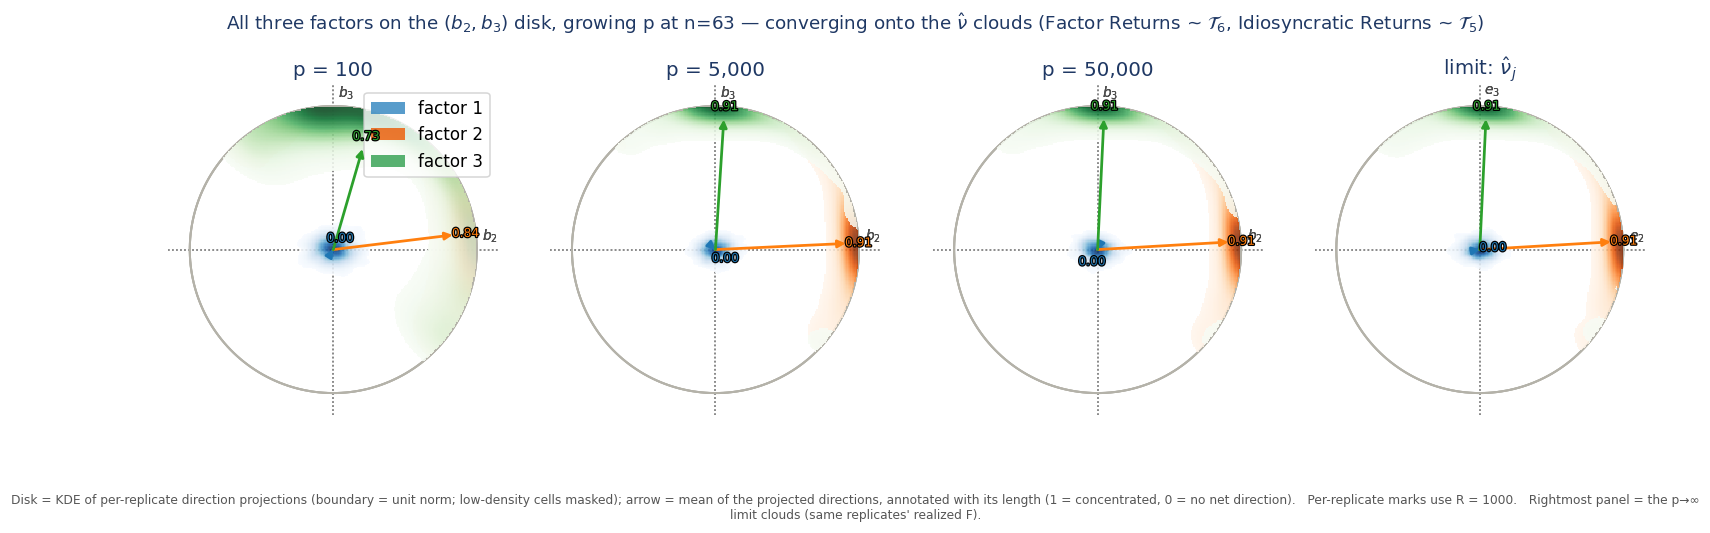

In [8]:
def all_factors_disk(at, *, coords="hd", axis_prefix="b"):
    """All three factors' clouds + mean arrows on one (2,3)-plane disk."""
    return [DiskDensity(f"{coords}2", f"{coords}3", factor=f, at=at, mean_arrow=True,
                        label=f"factor {f}",
                        labels=(rf"${axis_prefix}_2$", rf"${axis_prefix}_3$"))
            for f in (1, 2, 3)]


_P_STEPS = [100, 5000, 50000]
fig, _ = grid(
    df_p, "p", factors=[1] * (len(_P_STEPS) + 1),        # 4 layout columns, marks pinned
    col_titles=[f"p = {v:,}" for v in _P_STEPS] + [r"limit: $\hat\nu_j$"],
    rows=[Row(cells=[all_factors_disk({"p": v}) for v in _P_STEPS]
                    + [all_factors_disk({"p": 50000}, coords="nud", axis_prefix="e")],
              height=1.0)],
    sharey=False, figsize=(15.5, 4.9),
    suptitle=rf"All three factors on the $(b_2, b_3)$ disk, growing p at n=63 — "
             rf"converging onto the $\hat\nu$ clouds {_TAILS}",
    caption_extra="Rightmost panel = the p→∞ limit clouds (same replicates' realized F).",
    formats=FIG_FORMATS, out_path=out("ex6_all_factors_growing_p"))
show(fig)


## The estimates projected into the $(b_1, b_2)$ plane (raw)

Each dot is one replicate's plain coordinate pair
$(\langle b_1, h_j\rangle, \langle b_2, h_j\rangle)$ — sign-folded, otherwise
untransformed, so the radial deficit includes every loss (other axes and the
out-of-subspace floor). The check below confirms the arrows against the recorded
$\sin^2_j$.

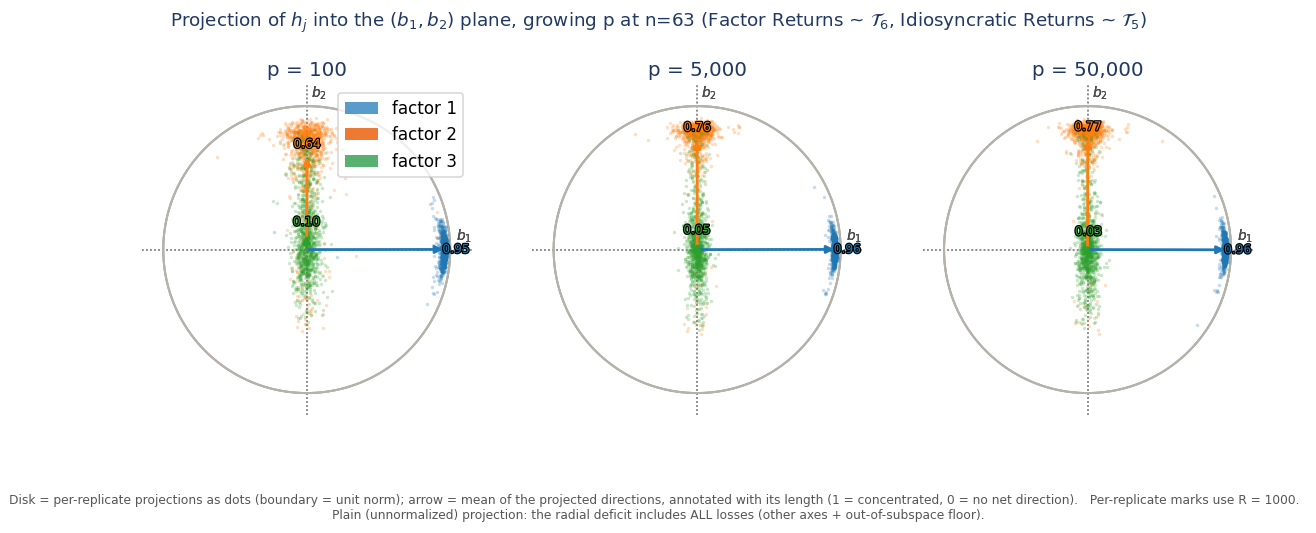

cos∠(h_j, b_j): from coordinates vs implied by sin²_j (identical by construction):


cos_own  cos_implied  angle_deg
p     j                                 
100   1    0.951        0.951     17.963
      2    0.677        0.677     47.375
      3    0.405        0.405     66.123
500   1    0.956        0.956     17.129
      2    0.760        0.760     40.523
      3    0.633        0.633     50.720
5000  1    0.956        0.956     17.046
      2    0.782        0.782     38.536
      3    0.690        0.690     46.398
10000 1    0.956        0.956     17.041
      2    0.783        0.783     38.425
      3    0.692        0.692     46.190
20000 1    0.956        0.956     17.044
      2    0.783        0.783     38.426
      3    0.693        0.693     46.135
50000 1    0.956        0.956     17.042
      2    0.784        0.784     38.375
      3    0.694        0.694     46.074

In [9]:
def frame_disk(at, coords, *, axes=(1, 2), prefix="b"):
    # All three factors as raw dots (one per replicate) + mean arrow, vs a chosen frame.
    a1, a2 = axes
    return [DiskDensity(f"{coords}{a1}", f"{coords}{a2}", factor=f, at=at, mean_arrow=True,
                        kde=False, scatter=10**6,          # every replicate as a dot
                        label=f"factor {f}",
                        labels=(rf"${prefix}_{a1}$", rf"${prefix}_{a2}$"))
            for f in (1, 2, 3)]


fig, _ = grid(
    df_p, "p", factors=[1] * len(_P_STEPS),
    col_titles=[f"p = {v:,}" for v in _P_STEPS],
    rows=[Row(cells=[frame_disk({"p": v}, "hf") for v in _P_STEPS],
              height=1.0)],
    sharey=False, figsize=(11.8, 4.9), formats=FIG_FORMATS,
    suptitle=rf"Projection of $h_j$ into the $(b_1, b_2)$ plane, growing p at n=63 {_TAILS}",
    caption_extra="Plain (unnormalized) projection: the radial deficit includes ALL "
                  "losses (other axes + out-of-subspace floor).",
    out_path=out("ex6_bframe_raw_growing_p"))
show(fig)

# The parallelism check: disk arrows vs the value implied by the recorded sin²_j.
_C = df_p[["hb1", "hb2", "hb3"]].to_numpy()
_chk = df_p.assign(cos_own=np.abs(_C[np.arange(len(df_p)), df_p["j"].to_numpy() - 1]),
                   cos_implied=np.sqrt(1 - df_p["sin2_j"]))
_t = _chk.groupby(["p", "j"])[["cos_own", "cos_implied"]].mean()
_t["angle_deg"] = np.degrees(np.arccos(_t["cos_own"]))
print("cos∠(h_j, b_j): from coordinates vs implied by sin²_j (identical by construction):")
display(_t.round(3))

## The angle gauge

In the projection strip the angle to the axis is encoded in a *coordinate*, not in the
visual angle. Here each replicate is placed **on the unit arc** at its true
$\angle(b_j, h_j)$, so the polar angle in the panel is the actual angle between the
estimate and its own population direction.

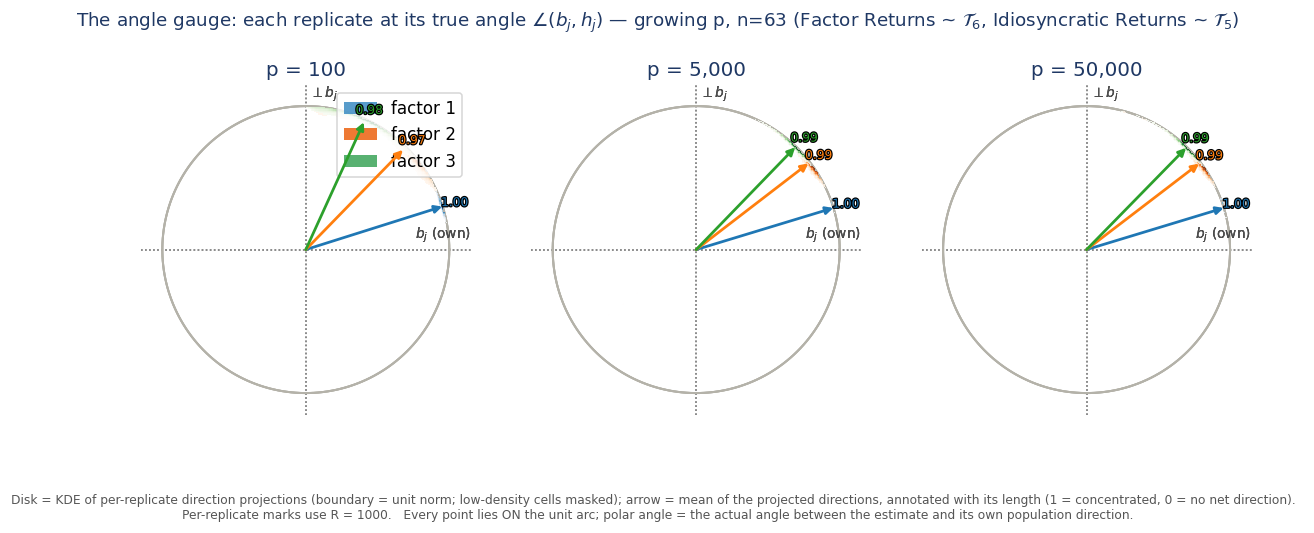

∠(b_j, h_j) in degrees, per p and factor:


median    q1    q3   p95
p     j                          
100   1    17.0  15.4  18.9  22.9
      2    41.5  36.5  51.2  79.1
      3    64.5  56.0  75.2  86.8
500   1    16.7  15.4  18.3  21.2
      2    36.2  32.9  41.0  66.6
      3    47.9  44.1  52.7  73.1
5000  1    16.6  15.4  18.1  20.8
      2    35.0  32.5  38.9  57.1
      3    44.3  41.8  47.7  59.4
10000 1    16.6  15.4  18.1  20.7
      2    35.0  32.4  38.6  56.8
      3    44.2  41.6  47.4  59.2
20000 1    16.6  15.4  18.1  20.6
      2    34.9  32.4  38.7  57.0
      3    44.2  41.6  47.2  59.0
50000 1    16.6  15.4  18.1  20.6
      2    34.9  32.4  38.8  55.9
      3    44.2  41.5  47.0  58.7

In [10]:
fig, _ = grid(
    df_p, "p", factors=[1] * len(_P_STEPS),
    col_titles=[f"p = {v:,}" for v in _P_STEPS],
    rows=[Row(cells=[[DiskDensity("ang_c", "ang_s", factor=f, at={"p": v}, mean_arrow=True,
                                  label=f"factor {f}",
                                  labels=(r"$b_j$ (own)", r"$\perp b_j$"))
                      for f in (1, 2, 3)]
                     for v in _P_STEPS],
              height=1.0)],
    sharey=False, figsize=(11.8, 4.9), formats=FIG_FORMATS,
    suptitle=rf"The angle gauge: each replicate at its true angle "
             rf"$\angle(b_j, h_j)$ — growing p, n=63 {_TAILS}",
    caption_extra="Every point lies ON the unit arc; polar angle = the actual angle "
                  "between the estimate and its own population direction.",
    out_path=out("ex6_angle_gauge_growing_p"))
show(fig)

print("∠(b_j, h_j) in degrees, per p and factor:")
_a = df_p.assign(ang_deg=np.degrees(np.arccos(df_p["ang_c"])))
display(_a.groupby(["p", "j"])["ang_deg"]
          .agg(median="median", q1=lambda s: s.quantile(0.25),
               q3=lambda s: s.quantile(0.75), p95=lambda s: s.quantile(0.95))
          .round(1))